In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

box_model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(box_model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.4496
Epoca [10/100] | Loss: 0.1958
Epoca [20/100] | Loss: 0.0602
Epoca [30/100] | Loss: 0.0232
Epoca [40/100] | Loss: 0.0116
Epoca [50/100] | Loss: 0.0068
Epoca [60/100] | Loss: 0.0048
Epoca [70/100] | Loss: 0.0039
Epoca [80/100] | Loss: 0.0036
Epoca [90/100] | Loss: 0.0032
Epoca [100/100] | Loss: 0.0030

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 1.0000
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0053
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

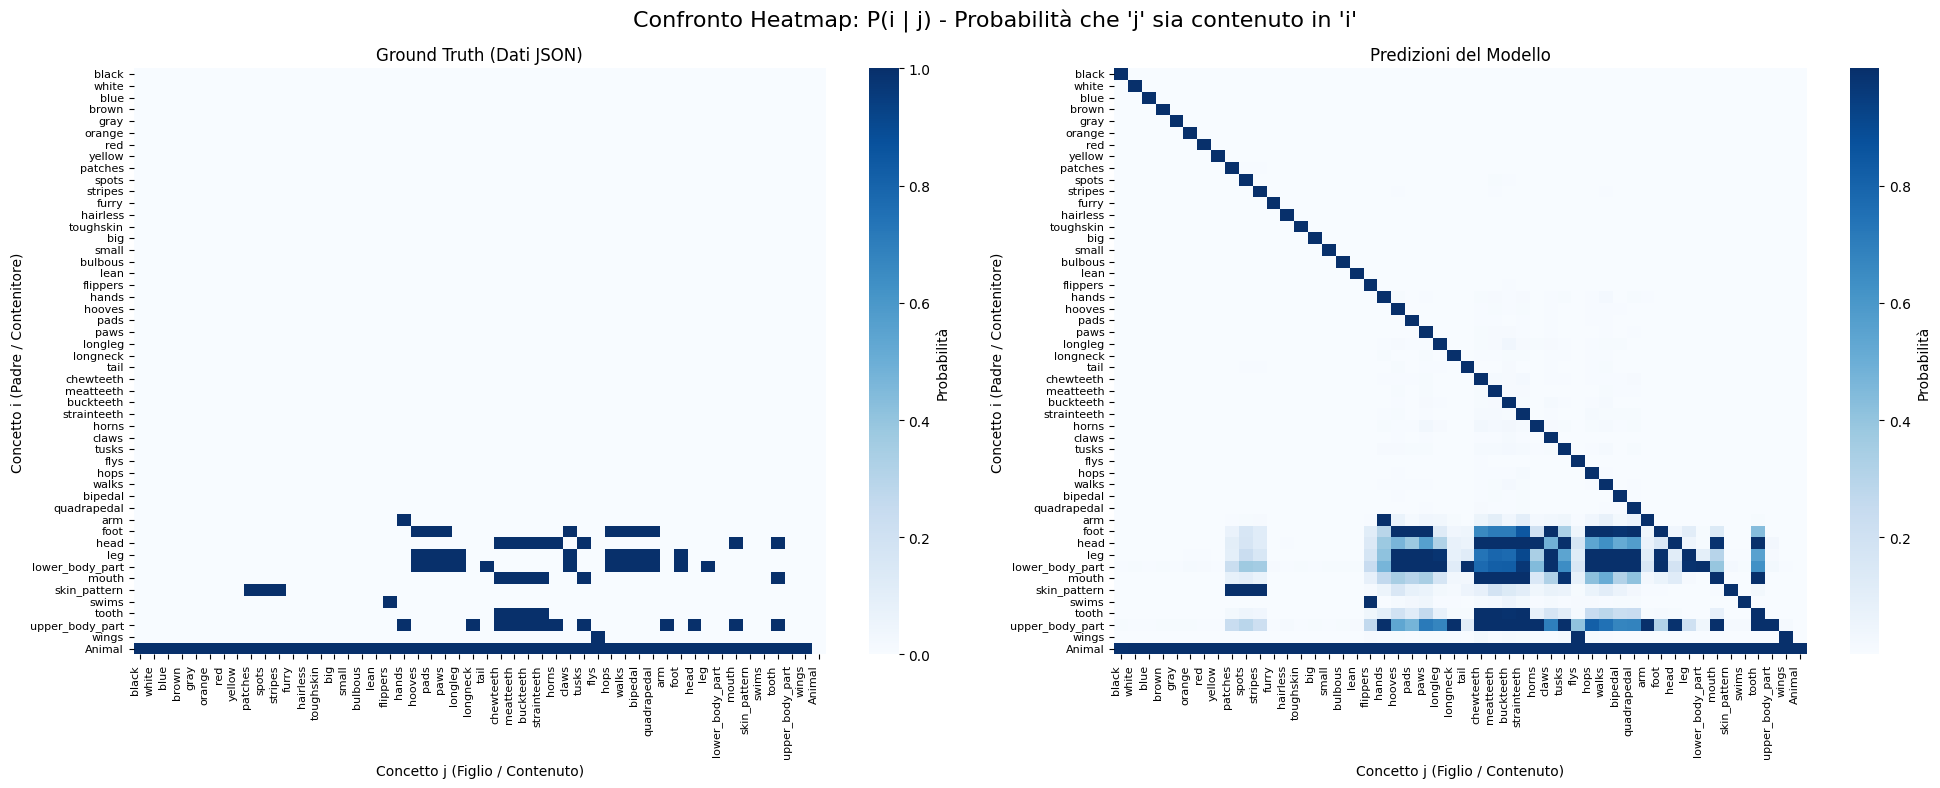

In [10]:
visualize_heatmap_compare(box_model, dataset, concept2id, id2concept)

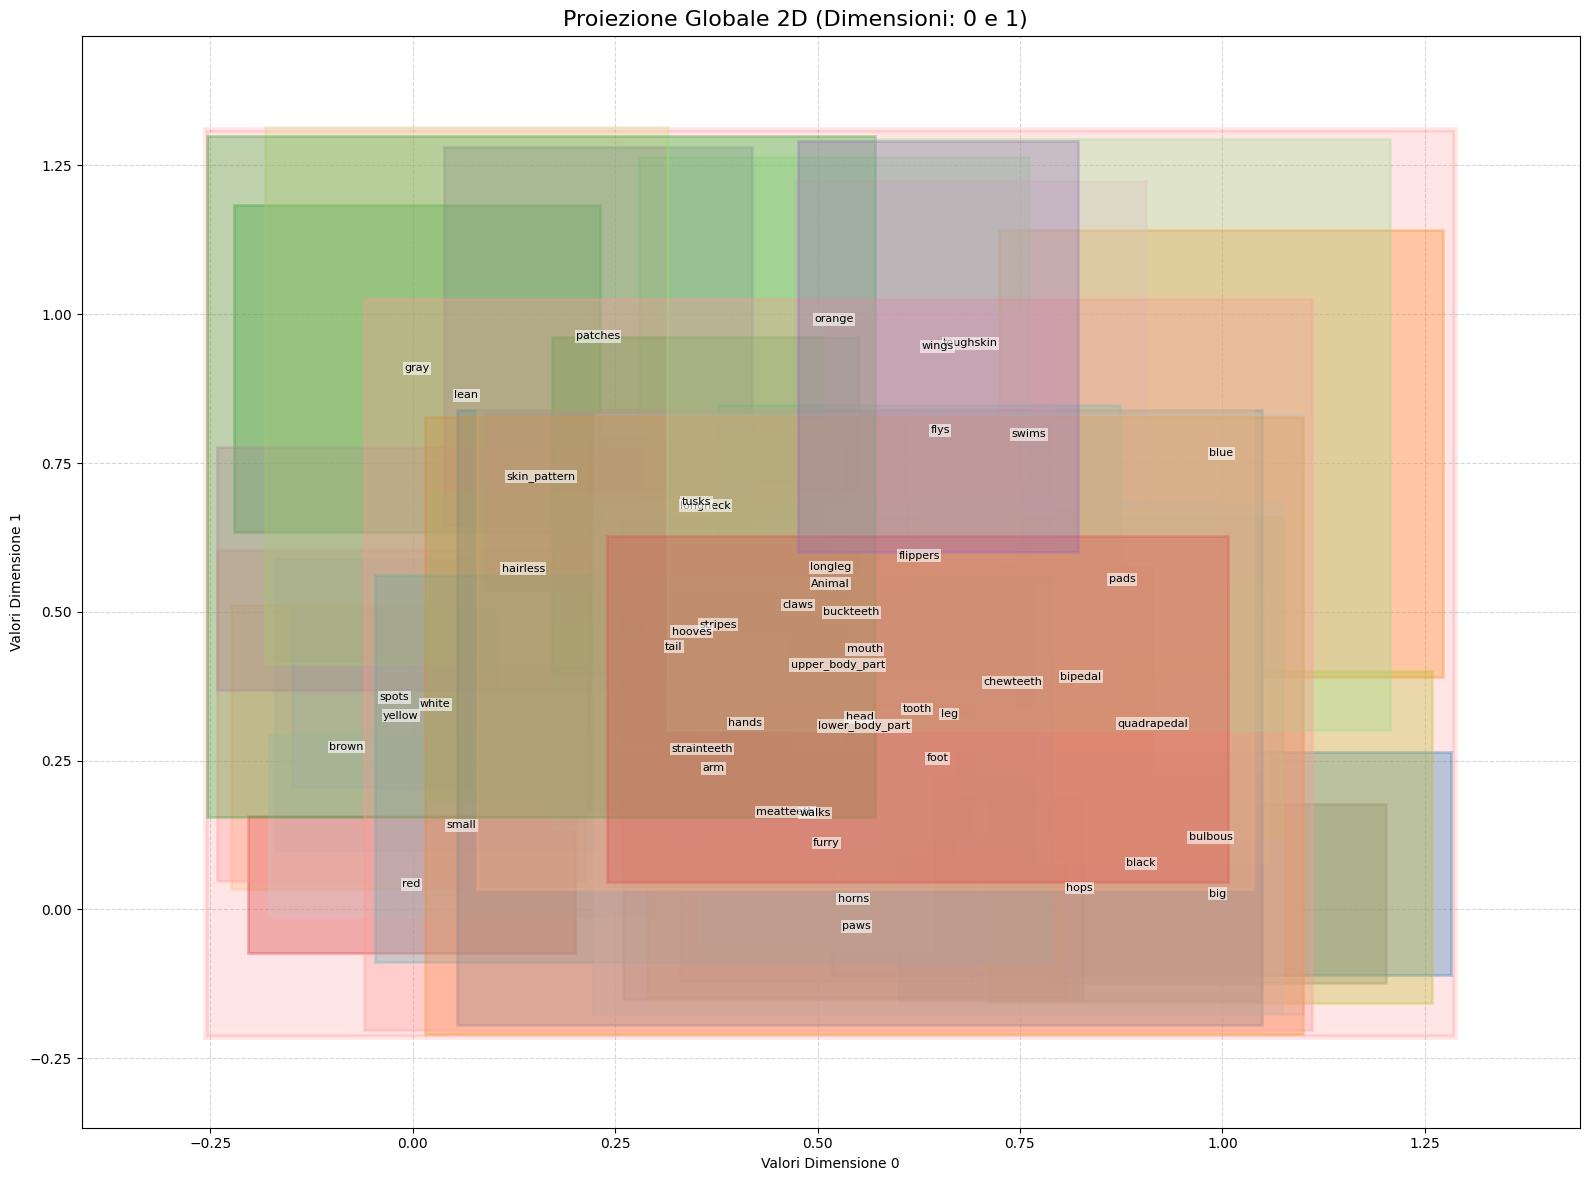

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

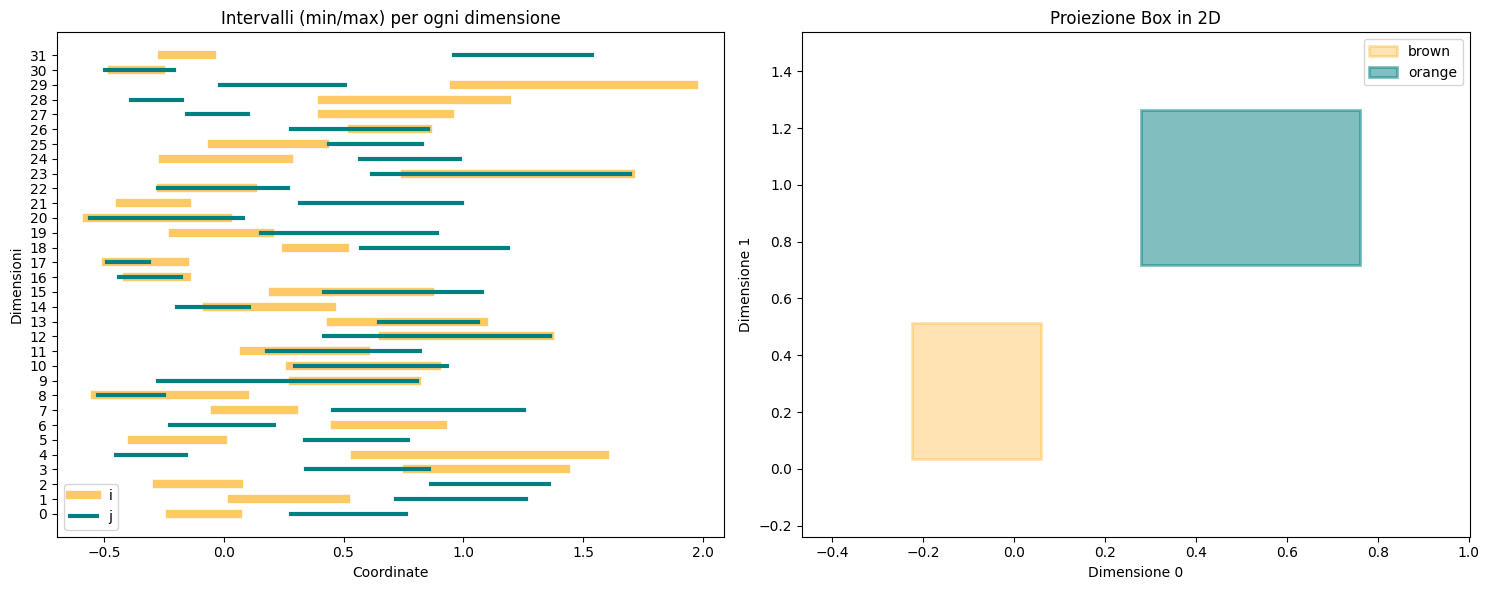

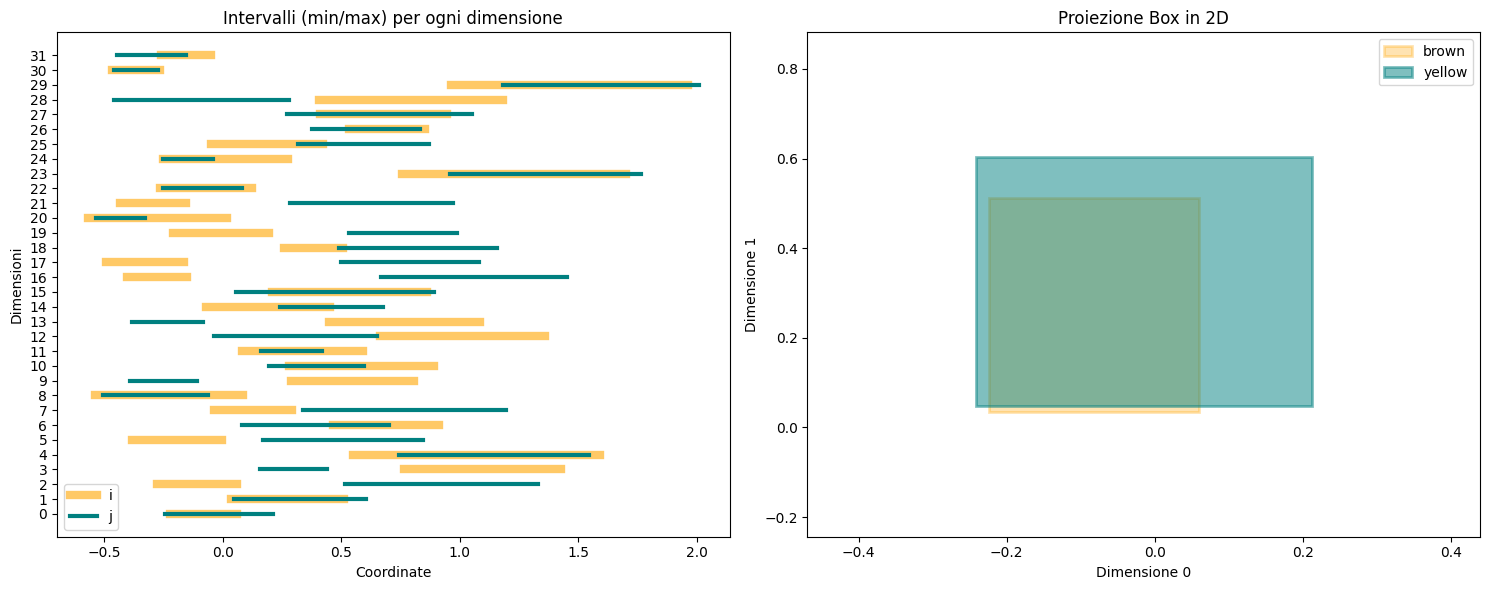

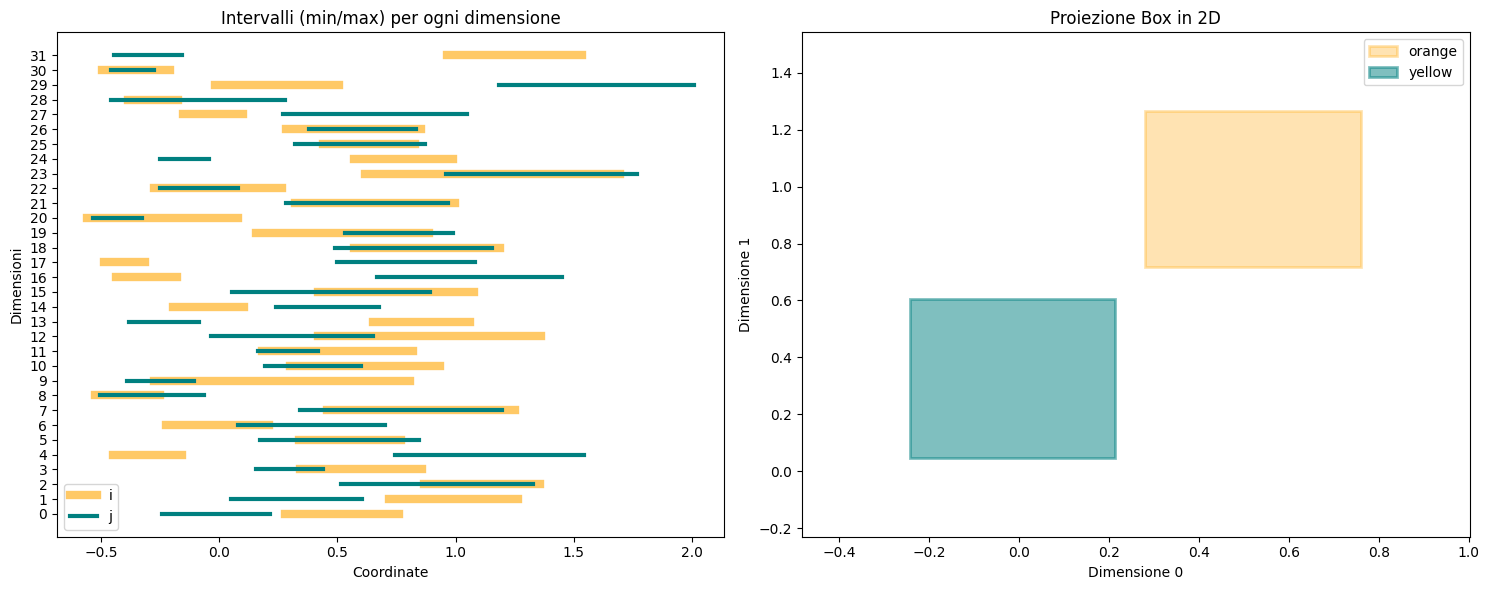

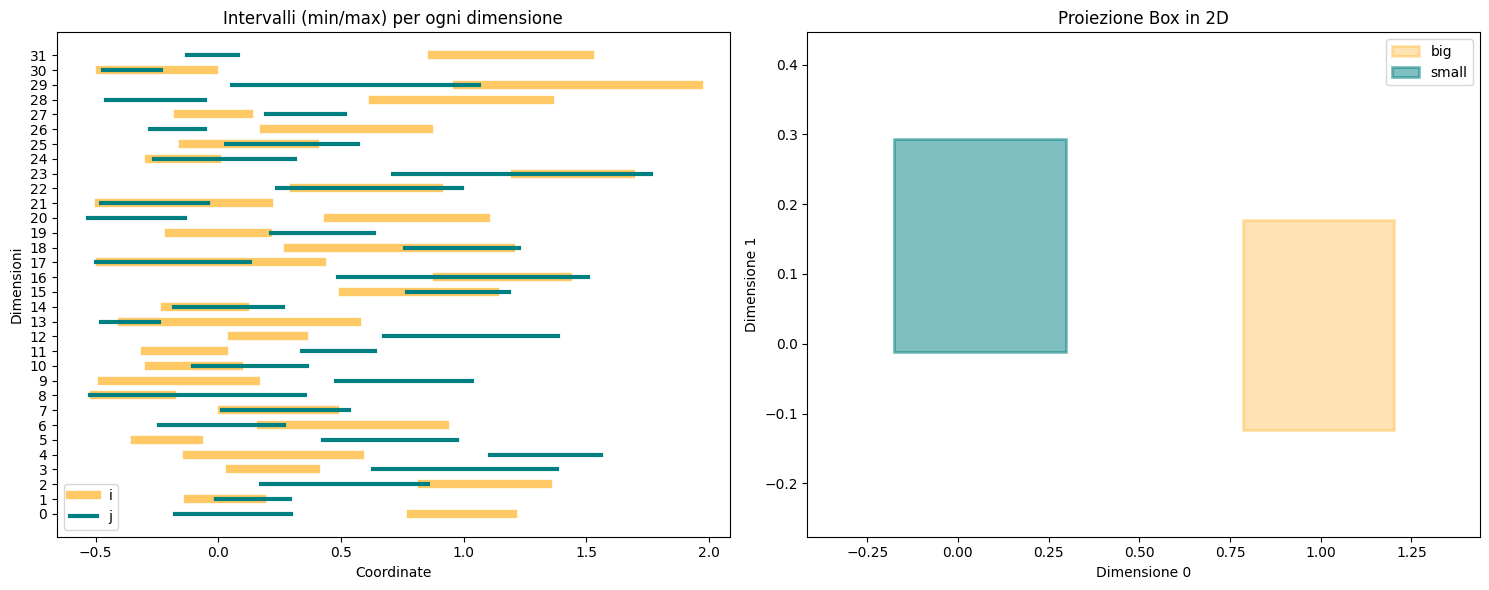

In [12]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "orange")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "brown", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "orange", "yellow")
visualize_concept_hierarchy(box_model, id2concept, concept2id, "big", "small")

### Save boxes

In [13]:
from src.CHM.model import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

In [14]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.2876, 1.3087, 1.4323, 1.4864, 1.6798, 1.0254, 1.0823, 1.3460, 1.1776,
         1.0522, 1.0047, 1.0153, 1.4826, 1.1644, 1.0021, 1.2692, 1.5245, 1.2484,
         1.2629, 0.9930, 1.2091, 1.0757, 1.0765, 1.8084, 1.1152, 0.9236, 0.9254,
         1.1091, 1.4062, 2.0444, 1.2625, 1.6645]])
Coordinate z (min) per 'wings': tensor([[ 0.4755,  0.6003,  0.0462,  0.0330, -0.4206,  0.3698,  0.2804,  0.5297,
         -0.5312,  0.3489, -0.2704,  0.0693, -0.1628,  0.1976,  0.1083, -0.3106,
          0.3726, -0.5444,  0.4939, -0.2712, -0.5137, -0.4592, -0.2639,  0.2059,
          0.4904,  0.1324, -0.0189,  0.2132,  0.4369,  0.3858,  0.5494, -0.4590]])


## CBM

### Load dataset

In [15]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [16]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [17]:
box_dict = get_box_dict(box_model, id2concept)

In [18]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[1.2876, 1.3087, 1.4323, 1.4864, 1.6798, 1.0254, 1.0823, 1.3460, 1.1776,
         1.0522, 1.0047, 1.0153, 1.4826, 1.1644, 1.0021, 1.2692, 1.5245, 1.2484,
         1.2629, 0.9930, 1.2091, 1.0757, 1.0765, 1.8084, 1.1152, 0.9236, 0.9254,
         1.1091, 1.4062, 2.0444, 1.2625, 1.6645]])
Coordinate z (min) per 'wings': tensor([[ 0.4755,  0.6003,  0.0462,  0.0330, -0.4206,  0.3698,  0.2804,  0.5297,
         -0.5312,  0.3489, -0.2704,  0.0693, -0.1628,  0.1976,  0.1083, -0.3106,
          0.3726, -0.5444,  0.4939, -0.2712, -0.5137, -0.4592, -0.2639,  0.2059,
          0.4904,  0.1324, -0.0189,  0.2132,  0.4369,  0.3858,  0.5494, -0.4590]])


In [19]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.CHM.model import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


In [20]:
from src.CHM.model import ConceptBottleneckClassifier, ConceptPredictor
from src.CHM.train import train_cbm_classifier, sequential_training, train_concept_predictor
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier, plot_test_results, test_sequential_cbm

### CBM with boxes

#### Train

In [21]:
b_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
b_cls_optimizer = torch.optim.Adam(b_cls.parameters(), lr=0.001)
b_cls_criterion = nn.CrossEntropyLoss()

b_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
b_concept_optimizer = torch.optim.Adam(b_concept_predictor.parameters(), lr=0.001)
b_concept_criterion = nn.BCEWithLogitsLoss()

info = "boxes"

b_conc_history, b_cls_history = sequential_training(
    b_cls,
    b_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    b_cls_optimizer,  
    b_concept_optimizer,
    b_cls_criterion,
    b_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5615 | Acc: 95.9327 || Val Loss: 2.5832 | Val Acc: 97.0640
Loss: 2.2490 | Acc: 97.4241 || Val Loss: 2.3505 | Val Acc: 97.2344
Loss: 1.9618 | Acc: 97.7457 || Val Loss: 2.2099 | Val Acc: 97.4021
Loss: 1.7804 | Acc: 97.9535 || Val Loss: 2.1948 | Val Acc: 97.4573
Loss: 1.6645 | Acc: 98.0759 || Val Loss: 2.1695 | Val Acc: 97.4900
Loss: 1.5665 | Acc: 98.1915 || Val Loss: 2.1615 | Val Acc: 97.5253
Loss: 1.4905 | Acc: 98.2801 || Val Loss: 2.1642 | Val Acc: 97.5028
Loss: 1.4347 | Acc: 98.3451 || Val Loss: 2.1736 | Val Acc: 97.5264
Loss: 1.3873 | Acc: 98.3891 || Val Loss: 2.1500 | Val Acc: 97.5382
Loss: 1.3362 | Acc: 98.4550 || Val Loss: 2.1772 | Val Acc: 97.5092
Loss: 1.2993 | Acc: 98.5024 || Val Loss: 2.1911 | Val Acc: 97.5157
Loss: 1.2713 | Acc: 98.5266 || Val Loss: 2.2618 | Val Acc: 97.4985
Loss: 1.2300 | Acc: 98.5779 || Val Loss: 2.2207 | Val Acc: 97.5350
Loss: 1.2132 | Acc: 98.6047 || Val Loss: 2.2290 | Val Ac

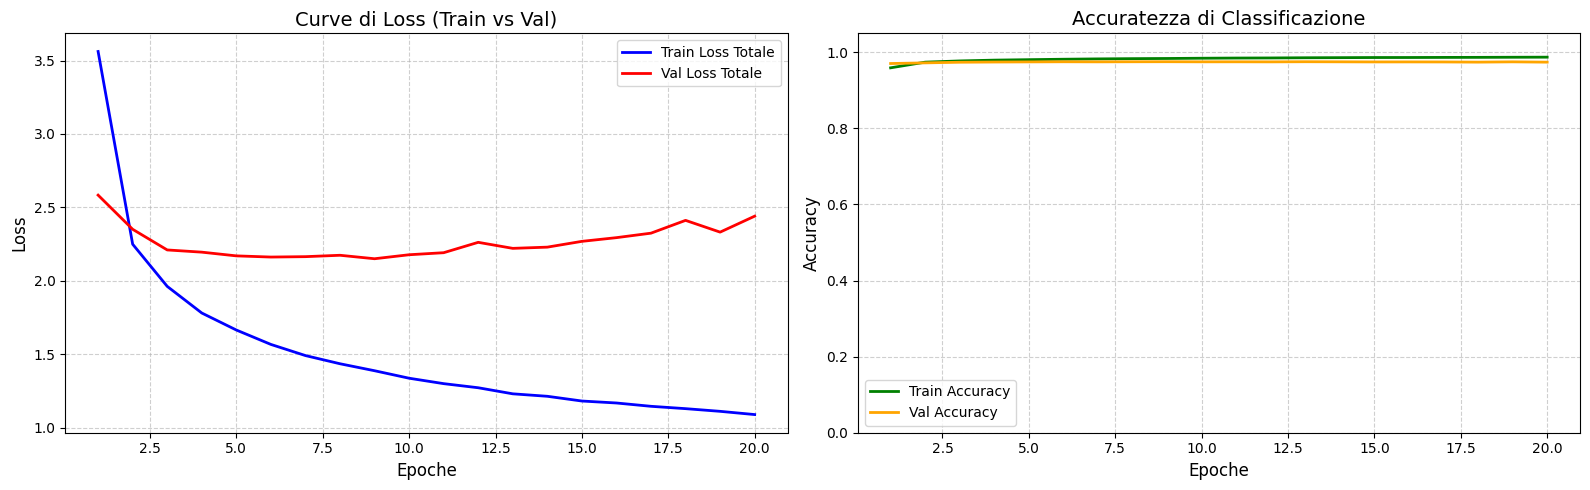

In [22]:
from src.CHM.train import plot_history
plot_history(b_conc_history)

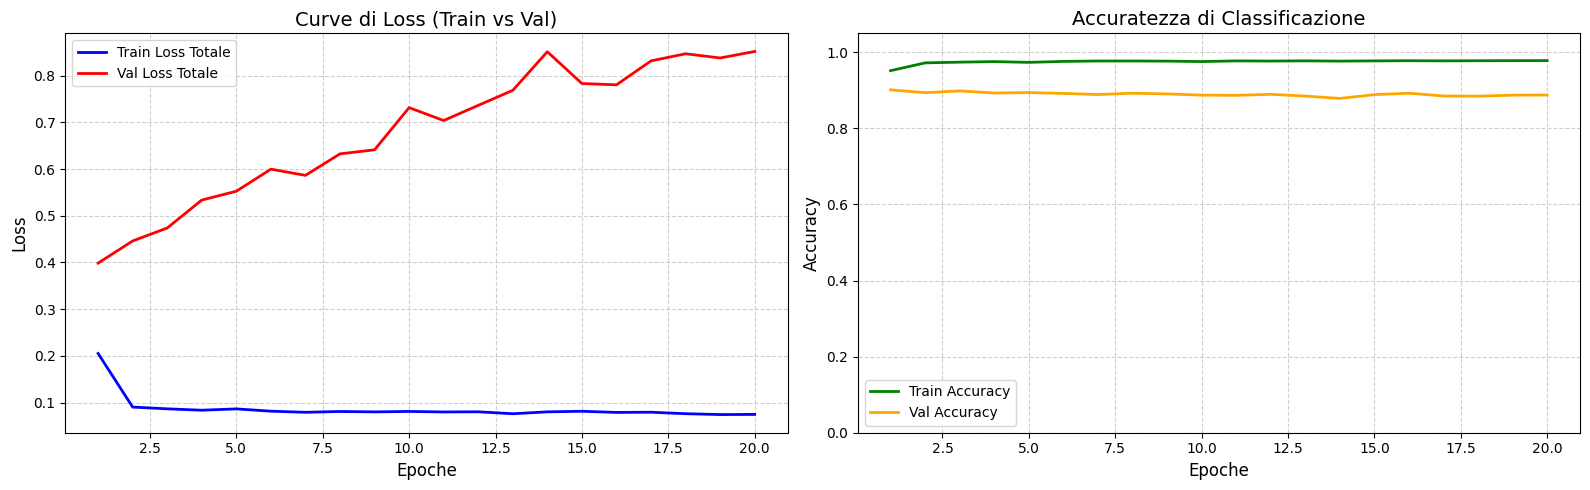

In [23]:
plot_history(b_cls_history)

#### Test

In [24]:
accuracy, preds, labels = test_sequential_cbm(
    b_cls,
    b_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 88.89% (6636/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.84      0.92      0.88       209
           1       0.91      0.84      0.87       170
           2       0.81      0.81      0.81        58
           3       0.77      0.79      0.78        38
           4       0.97      0.97      0.97       110
           5       0.93      0.90      0.91       149
           6       0.92      0.93      0.92       329
           7       0.87      0.86      0.87       207
           8       0.32      0.34      0.33        35
           9       0.73      0.83      0.78       100

   micro avg       0.87      0.88      0.87      1405
   macro avg       0.81      0.82      0.81      1405
weighted avg       0.87      0.88      0.87      1405



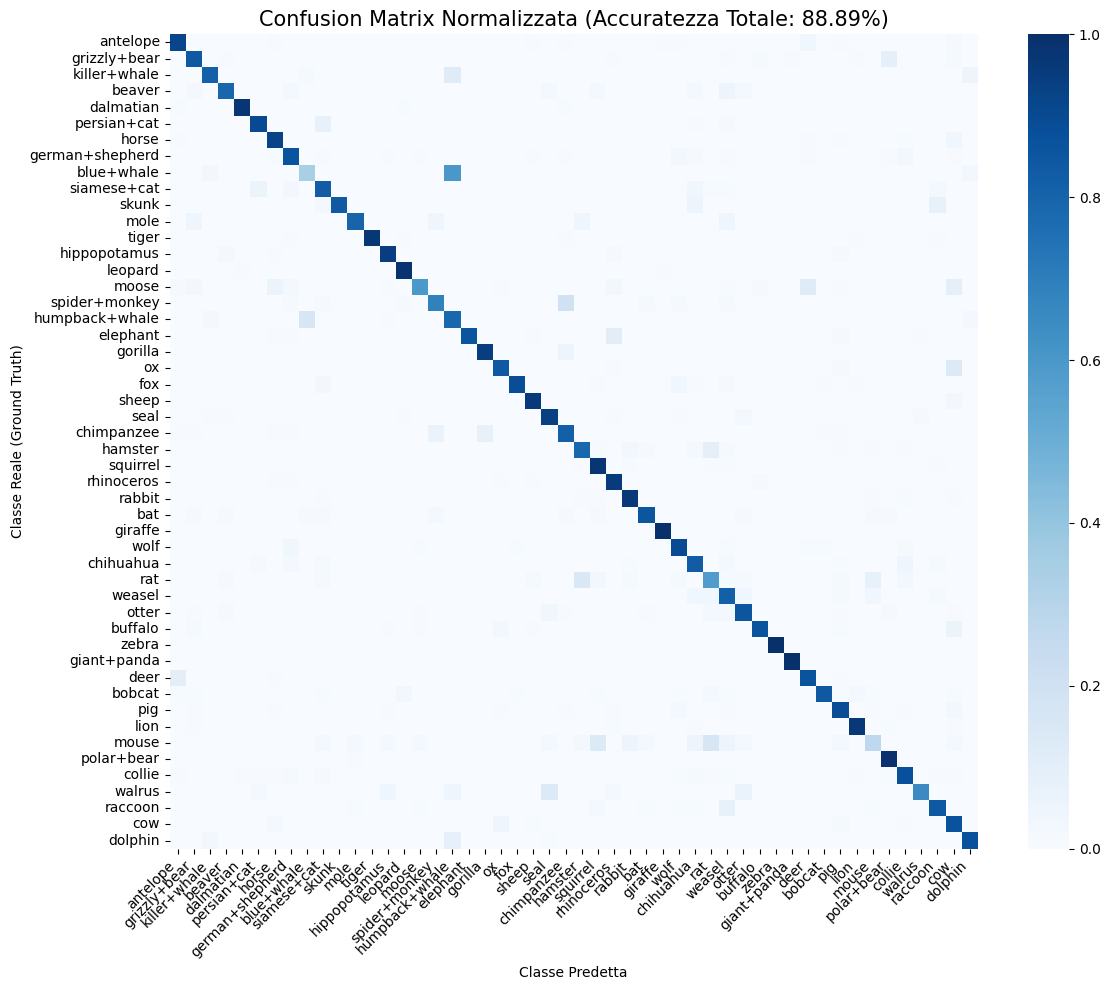


Analisi degli Errori Principali:
 - 28 volte: 'deer' è stato scambiato per 'antelope'
 - 23 volte: 'humpback+whale' è stato scambiato per 'blue+whale'
 - 22 volte: 'elephant' è stato scambiato per 'rhinoceros'
 - 21 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 20 volte: 'ox' è stato scambiato per 'cow'


In [25]:
plot_test_results(accuracy, preds, labels, class_names=classes)

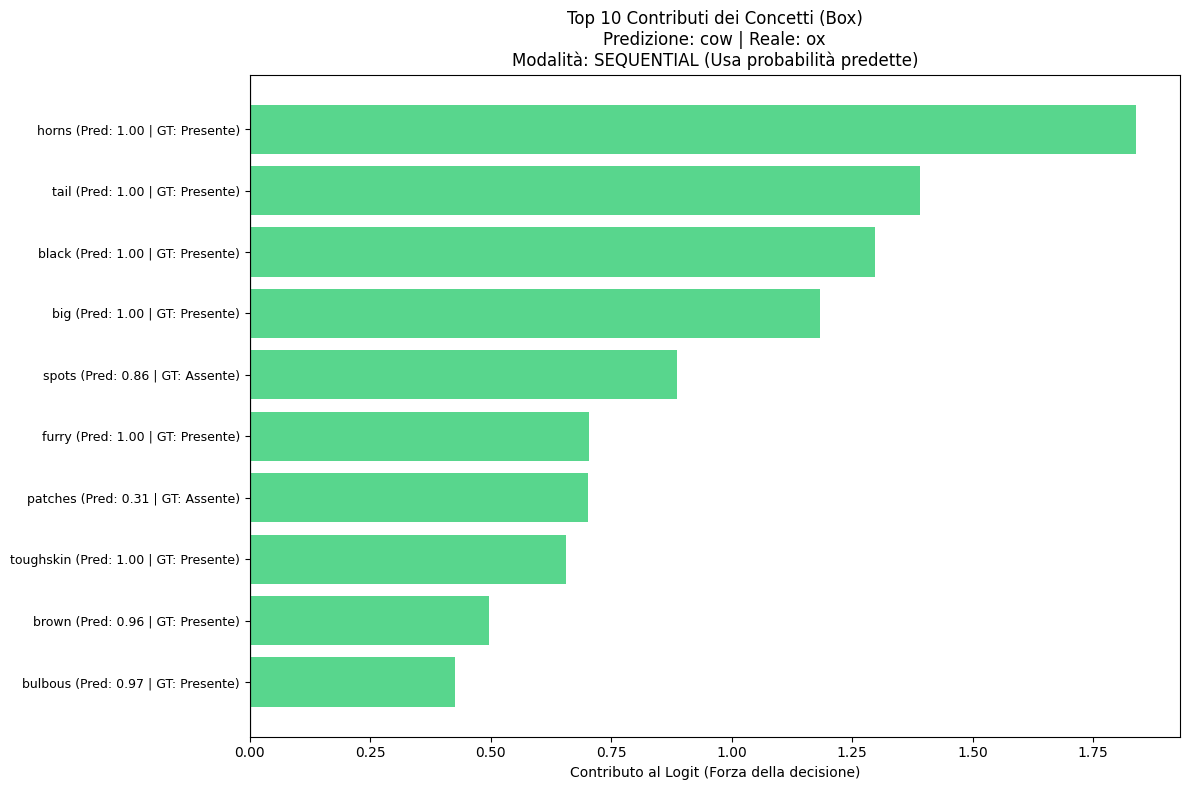

False

In [27]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    b_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=b_concept_predictor,
    target_class="ox"
)

### CBM with cond prob distrib

#### Train

In [36]:
info = "rel_matrix"
bipolar = True
cp_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
cp_optimizer = torch.optim.Adam(cp_cls.parameters(), lr=0.001)
cp_criterion = nn.CrossEntropyLoss()

cp_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
cp_concept_optimizer = torch.optim.Adam(cp_concept_predictor.parameters(), lr=0.001)
cp_concept_criterion = nn.BCEWithLogitsLoss()

cp_conc_history, cp_cls_history = sequential_training(
    cp_cls,
    cp_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    cp_optimizer,  
    cp_concept_optimizer,
    cp_criterion,
    cp_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5597 | Acc: 95.9249 || Val Loss: 2.5583 | Val Acc: 97.0067
Loss: 2.2516 | Acc: 97.4244 || Val Loss: 2.3663 | Val Acc: 97.2601
Loss: 1.9520 | Acc: 97.7445 || Val Loss: 2.2200 | Val Acc: 97.3999
Loss: 1.7824 | Acc: 97.9401 || Val Loss: 2.2012 | Val Acc: 97.4487
Loss: 1.6622 | Acc: 98.0763 || Val Loss: 2.1335 | Val Acc: 97.4889
Loss: 1.5678 | Acc: 98.1886 || Val Loss: 2.2130 | Val Acc: 97.4642
Loss: 1.4924 | Acc: 98.2716 || Val Loss: 2.1700 | Val Acc: 97.4825
Loss: 1.4337 | Acc: 98.3407 || Val Loss: 2.2223 | Val Acc: 97.4900
Loss: 1.3817 | Acc: 98.4014 || Val Loss: 2.1911 | Val Acc: 97.4739
Loss: 1.3367 | Acc: 98.4622 || Val Loss: 2.1888 | Val Acc: 97.5033
Loss: 1.3001 | Acc: 98.4878 || Val Loss: 2.2205 | Val Acc: 97.5066
Loss: 1.2643 | Acc: 98.5455 || Val Loss: 2.2082 | Val Acc: 97.5216
Loss: 1.2383 | Acc: 98.5708 || Val Loss: 2.3024 | Val Acc: 97.4669
Loss: 1.2085 | Acc: 98.6060 || Val Loss: 2.2413 | Val Ac

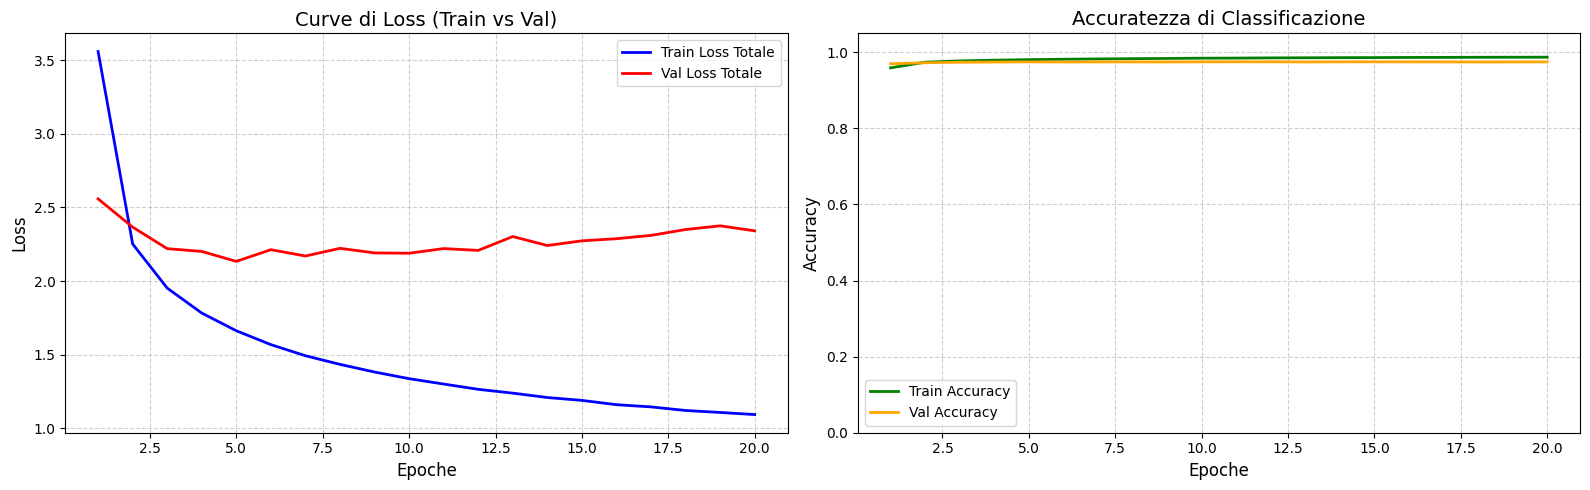

In [37]:
from src.CHM.train import plot_history
plot_history(cp_conc_history)

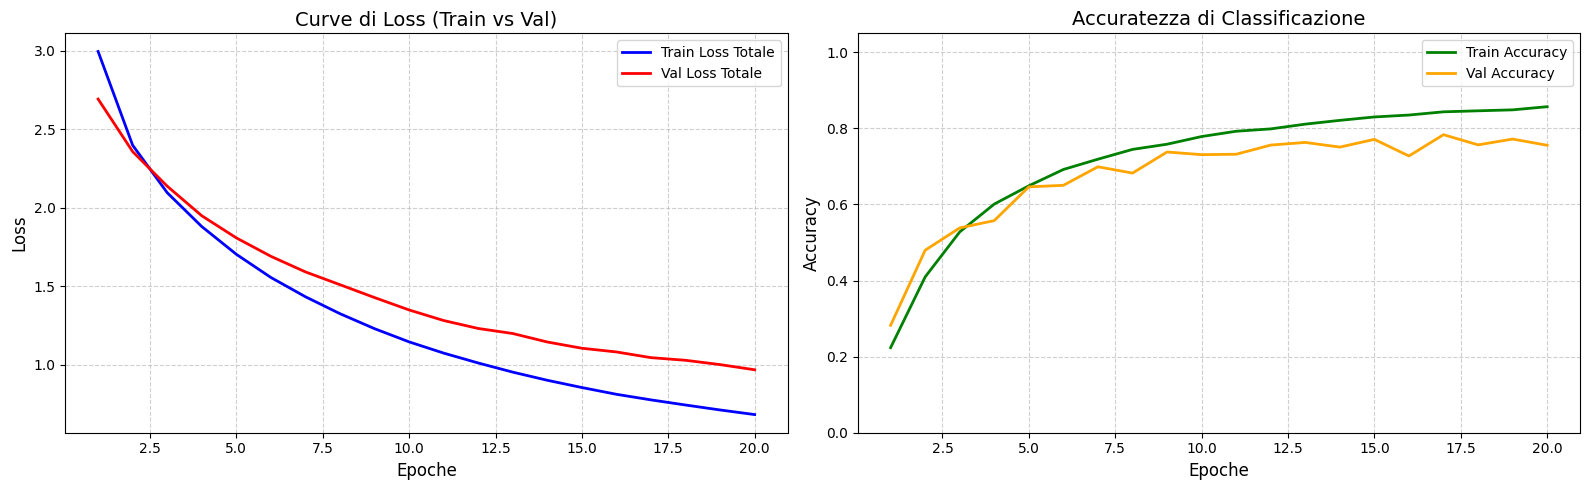

In [38]:
plot_history(cp_cls_history)

#### Test

In [39]:
cp_accuracy, cp_preds, cp_labels = test_sequential_cbm(
    cp_cls,
    cp_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 75.77% (5656/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.60      0.88      0.71       209
           1       0.90      0.86      0.88       170
           2       0.58      0.59      0.58        58
           3       0.79      0.58      0.67        38
           4       0.95      0.95      0.95       110
           5       0.52      0.07      0.13       149
           6       0.96      0.88      0.92       329
           7       0.65      0.81      0.72       207
           8       0.60      0.09      0.15        35
           9       0.33      0.11      0.17       100

   micro avg       0.76      0.69      0.72      1405
   macro avg       0.69      0.58      0.59      1405
weighted avg       0.73      0.69      0.68      1405



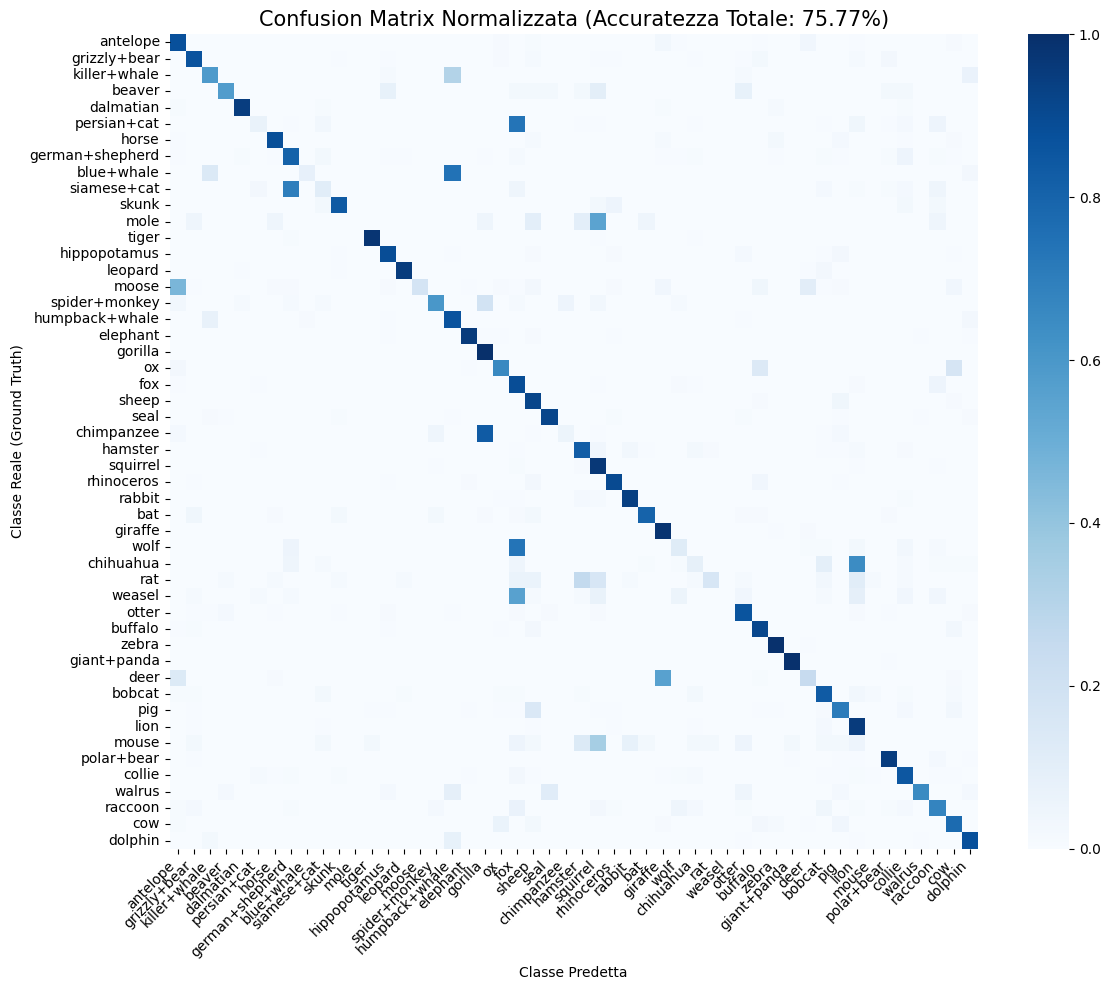


Analisi degli Errori Principali:
 - 150 volte: 'deer' è stato scambiato per 'giraffe'
 - 122 volte: 'chimpanzee' è stato scambiato per 'gorilla'
 - 110 volte: 'persian+cat' è stato scambiato per 'fox'
 - 87 volte: 'wolf' è stato scambiato per 'fox'
 - 73 volte: 'chihuahua' è stato scambiato per 'lion'


In [40]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

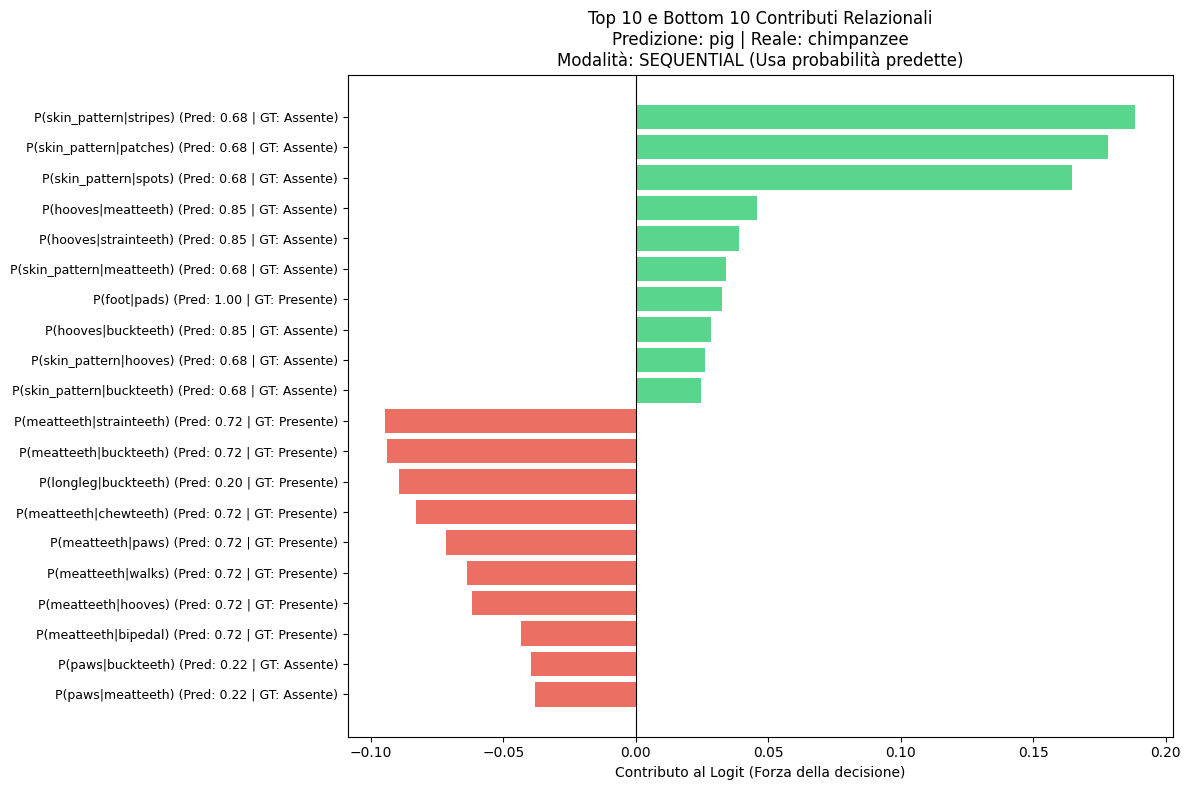

False

In [48]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=cp_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)

### CBM standard

In [49]:
info = "concepts"
c_cls = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
c_optimizer = torch.optim.Adam(c_cls.parameters(), lr=0.001)
c_criterion = nn.CrossEntropyLoss()


c_concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
c_concept_optimizer = torch.optim.Adam(c_concept_predictor.parameters(), lr=0.001)
c_concept_criterion = nn.BCEWithLogitsLoss()

c_conc_history, c_cls_history = sequential_training(
    c_cls,
    c_concept_predictor,
    train_dataloader, 
    val_dataloader,
    class_concept_matrix,
    box_tensors,
    c_optimizer,  
    c_concept_optimizer,
    c_criterion,
    c_concept_criterion,
    EPOCHS, 
    device,
    info,
    bipolar=False,
)

========== FASE 1: Addestramento Predittore Concetti (h -> c) ==========
Loss: 3.5774 | Acc: 95.9262 || Val Loss: 2.5688 | Val Acc: 97.0378
Loss: 2.2585 | Acc: 97.4038 || Val Loss: 2.4011 | Val Acc: 97.1567
Loss: 1.9589 | Acc: 97.7570 || Val Loss: 2.2386 | Val Acc: 97.3716
Loss: 1.7861 | Acc: 97.9463 || Val Loss: 2.1269 | Val Acc: 97.5178
Loss: 1.6618 | Acc: 98.0784 || Val Loss: 2.1249 | Val Acc: 97.5028
Loss: 1.5697 | Acc: 98.1855 || Val Loss: 2.1734 | Val Acc: 97.4557
Loss: 1.4913 | Acc: 98.2723 || Val Loss: 2.1530 | Val Acc: 97.4953
Loss: 1.4328 | Acc: 98.3431 || Val Loss: 2.1482 | Val Acc: 97.5285
Loss: 1.3827 | Acc: 98.4006 || Val Loss: 2.2254 | Val Acc: 97.4583
Loss: 1.3430 | Acc: 98.4435 || Val Loss: 2.2453 | Val Acc: 97.4675
Loss: 1.3012 | Acc: 98.4995 || Val Loss: 2.2207 | Val Acc: 97.4798
Loss: 1.2719 | Acc: 98.5372 || Val Loss: 2.2903 | Val Acc: 97.4246
Loss: 1.2372 | Acc: 98.5638 || Val Loss: 2.3148 | Val Acc: 97.4466
Loss: 1.2159 | Acc: 98.5913 || Val Loss: 2.2815 | Val Ac

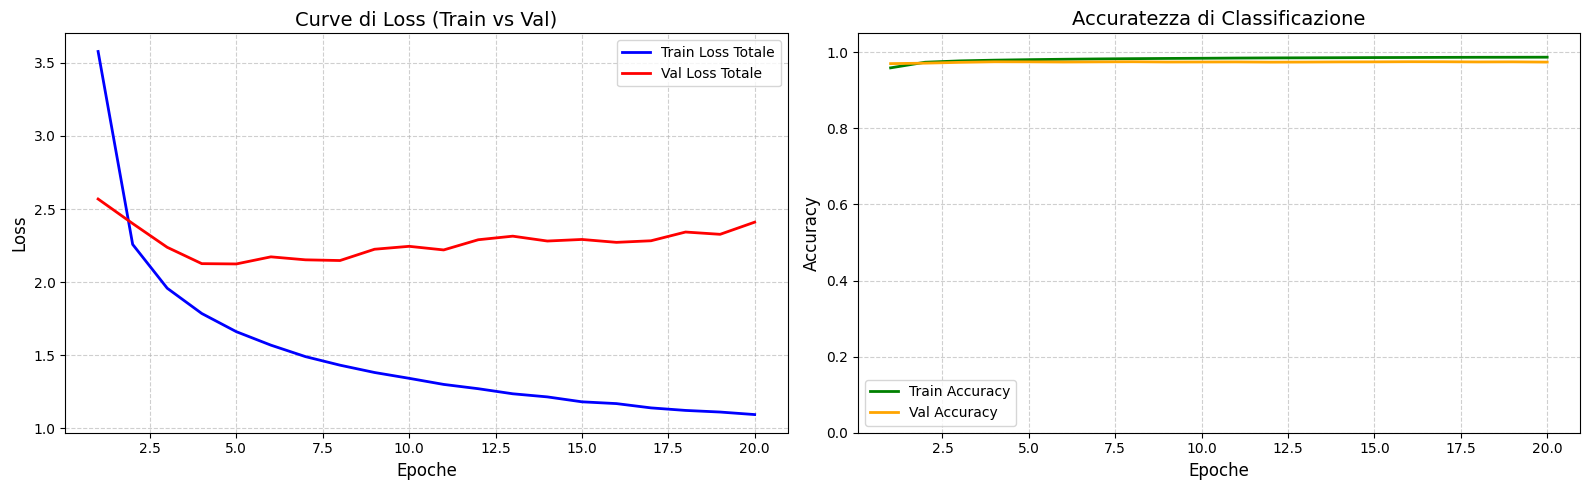

In [50]:
from src.CHM.train import plot_history
plot_history(c_conc_history)

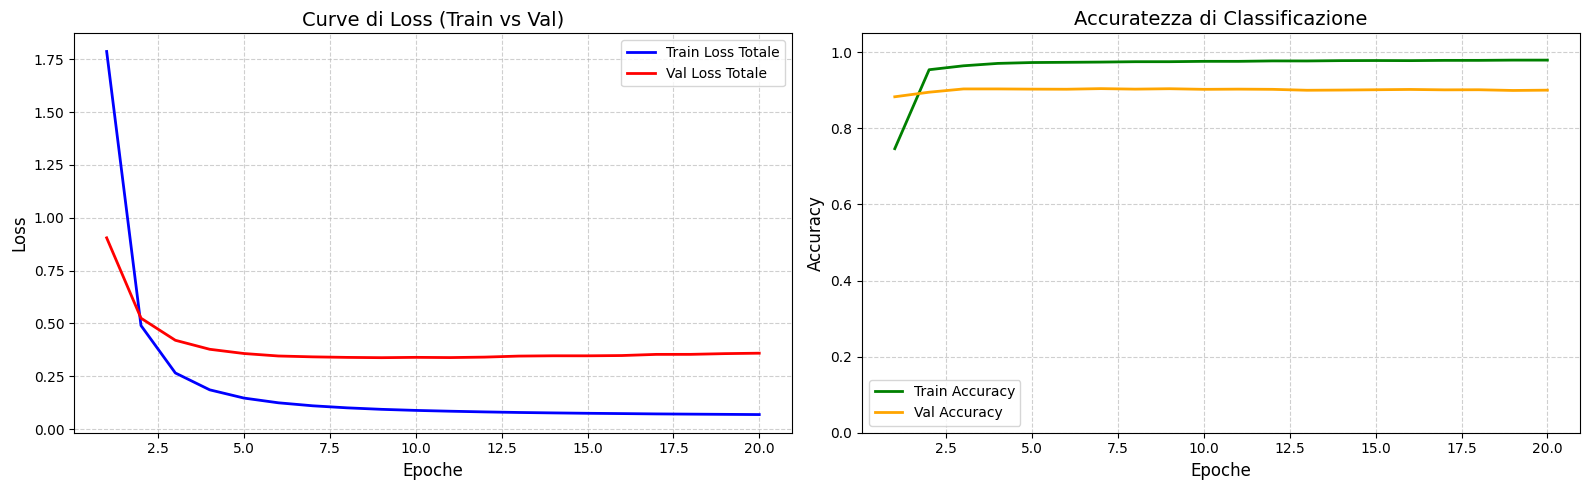

In [52]:
plot_history(c_cls_history)

In [53]:
c_accuracy, c_preds, c_labels = test_sequential_cbm(
    c_cls,
    c_concept_predictor,
    test_dataloader,
    box_tensors,
    class_concept_matrix,
    device,
    info,
)

Inizio valutazione sul Test Set (Modalità Sequenziale)...

Risultati Test Set (Sequenziale):
Accuratezza Totale: 90.56% (6760/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       0.89      0.91      0.90       209
           1       0.87      0.94      0.90       170
           2       0.86      0.84      0.85        58
           3       0.76      0.76      0.76        38
           4       0.96      0.98      0.97       110
           5       0.95      0.91      0.93       149
           6       0.93      0.94      0.93       329
           7       0.90      0.87      0.89       207
           8       0.42      0.31      0.36        35
           9       0.76      0.87      0.81       100

   micro avg       0.88      0.90      0.89      1405
   macro avg       0.83      0.84      0.83      1405
weighted avg       0.88      0.90      0.89      1405



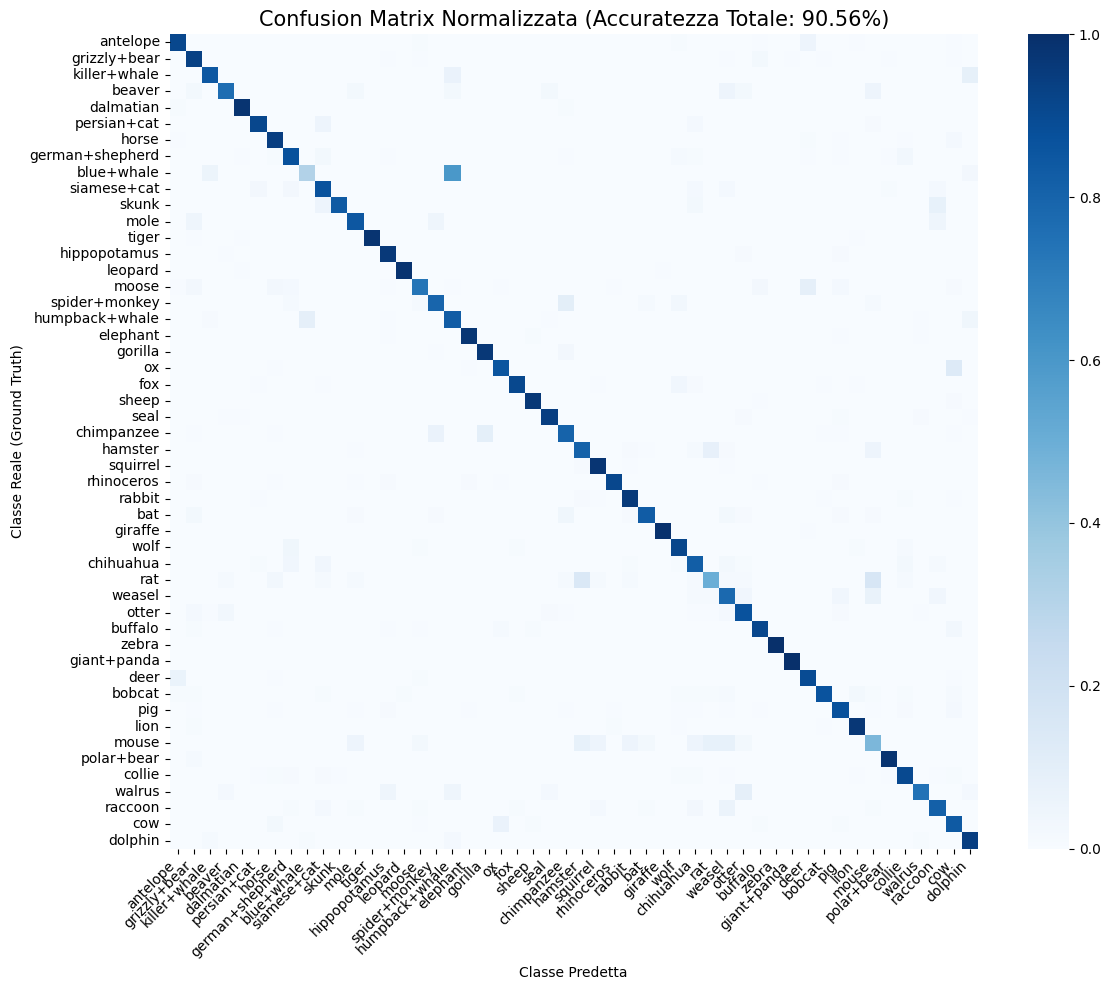


Analisi degli Errori Principali:
 - 21 volte: 'blue+whale' è stato scambiato per 'humpback+whale'
 - 19 volte: 'ox' è stato scambiato per 'cow'
 - 18 volte: 'cow' è stato scambiato per 'ox'
 - 17 volte: 'deer' è stato scambiato per 'antelope'
 - 14 volte: 'chimpanzee' è stato scambiato per 'gorilla'


In [54]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

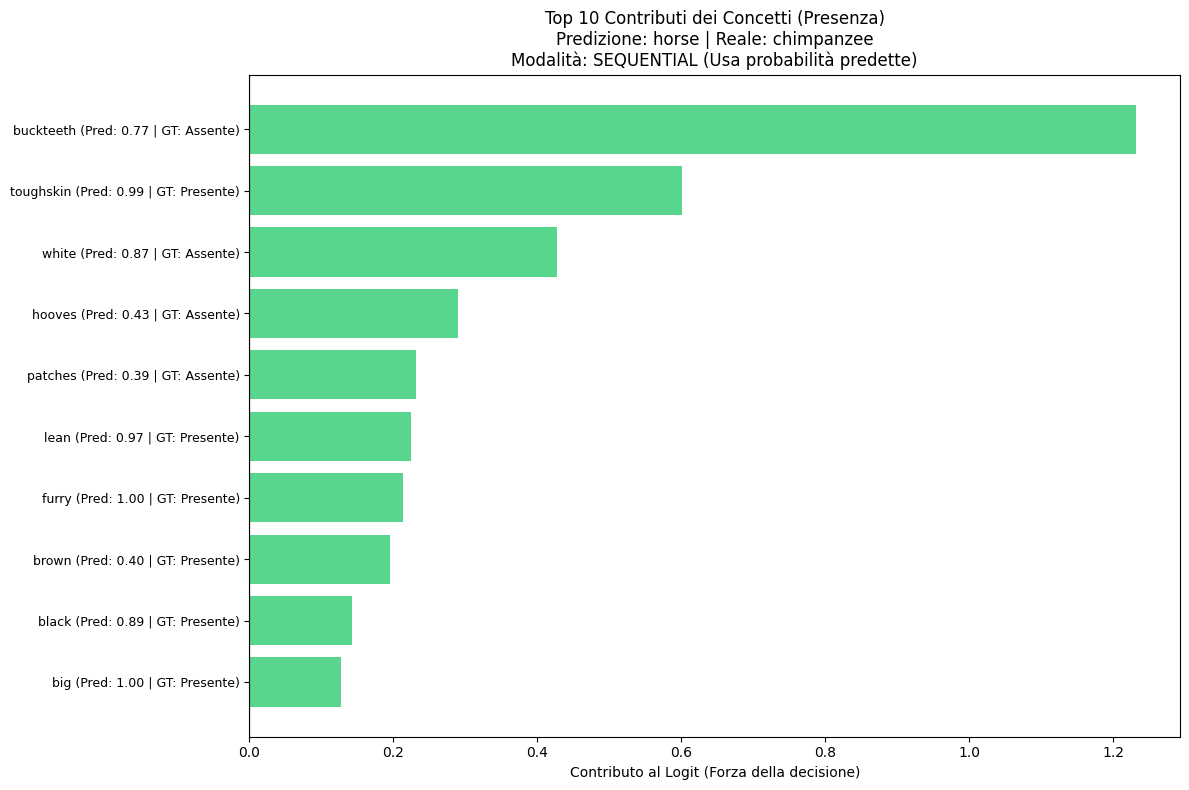

False

In [55]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    c_cls, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors,
    concept_predictor=c_concept_predictor,
    target_class="chimpanzee",
    info_type=info,
)